In [1]:
"""Smoke-test for the NEW Rossmann forecasting pipeline (hypertuning).

Runs the full feature-engineering -> target-transform -> inner-CV objective and
refit flow on a few real stores, then exercises hypertuning.optimize end-to-end
to validate the updated TimeSeriesCV(n_splits, train_size, test_size) API.
"""

import os
import logging
import warnings

import optuna
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error

from src import features
from src.preprocessing import preprocess_data
from src.engine import hypertuning, utils
from src.engine.cv import TimeSeriesCV
from src.engine.target_transformer import TargetTransformer
from src.settings import AppSettings

config = AppSettings.from_yaml('./config.yaml')

os.makedirs(config.path.log_dir, exist_ok=True)
assert os.path.exists(config.path.data_dir), \
    f"Data directory {config.path.data_dir} does not exist."

optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings("ignore")
logging.basicConfig(level=logging.INFO,
                    filename=config.path.logs,
                    format="%(levelname)s  %(message)s")

logger = logging.getLogger(__name__)

def plot_actual_vs_predicted(results, n_days_to_plot, n_days_offset):
        
    max_date = results.index.get_level_values("Date").max() - pd.Timedelta(days=n_days_offset)
    min_date = max_date - pd.Timedelta(days=n_days_to_plot)

    actuals_recent = results.loc[(slice(None), slice(min_date, max_date)), 'Sales_actual']
    preds_recent   = results.loc[(slice(None), slice(min_date, max_date)), 'Sales_predicted']

    plot_stores = actuals_recent.index.get_level_values("Store").unique()

    fig, ax = plt.subplots(figsize=(12, 2 * len(plot_stores)), nrows=len(plot_stores), sharex=True, sharey=False)

    for i, store in enumerate(plot_stores):

        actual_store_sales    = actuals_recent.loc[(store, slice(None))].copy()
        predicted_store_sales = preds_recent.loc[(store, slice(None))].copy()

        actual_store_sales.fillna(method='ffill', inplace=True)     # Forward fill to maintain continuity in the plot
        predicted_store_sales.fillna(method='ffill', inplace=True)  # Forward fill to maintain continuity in the plot

        actual_store_sales.plot(label="Actual", ax=ax[i])
        predicted_store_sales.plot(label="Predicted", ax=ax[i], linestyle='--')

        ax[i].set_ylabel("Store {}".format(store))
        ax[i].set_xlabel("Date")

    plt.suptitle("Actual vs Predicted Sales for Each Store (Last {} Days)".format(n_days_to_plot), fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])  # Adjust layout to make room for the suptitle
    plt.show()

c:\Users\m_kal\Downloads\rossmann_store_sales\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Config

`config` merges the CV and study settings so `hypertuning.optimize` can read the inner-CV keys (`n_inner_splits`, `inner_train_size`, `inner_test_size`) used by the new `TimeSeriesCV` API.

In [2]:
""" Read the Rossmann store sales dataset and preprocess it for modeling. """

sales = pd.read_csv(config.path.train)
stores = pd.read_csv(config.path.stores)

stores_to_use = [1, 2, 3]
stores = stores[stores['Store'].isin(stores_to_use)]

df = preprocess_data(sales, stores)

# Feature engineering + target transform (new pipeline)

In [3]:
# get all keys from the feature_engineering settings
config.horizon

<DateOffset: days=10>

In [4]:
y = df.set_index(['Store', 'Date'])['Sales']

X = (df
     .set_index(['Date'])
     .groupby('Store')
     .apply(lambda df: features.compute(df, config.feature_engineering, config.horizon)))

trf = TargetTransformer(forecast_horizon=pd.DateOffset(days=-config.horizon.days),
                        anchor_col='lag_days_0')
trf.fit(X)

y = trf.transform(y)    # forward difference target
X = X.loc[y.index]      # align features with target

# Single-trial smoke test of `_objective`

In [5]:
from optuna.trial import FixedTrial
from src.engine.hypertuning import _objective


num_days = X.index.get_level_values("Date").nunique()
cv_sizes = utils.compute_cv_sizes(num_days,
                                  config.horizon.days,
                                  config.cross_validation)

inner_cv = TimeSeriesCV(n_splits=config.cross_validation.n_inner_splits,
                        gap=config.horizon.days,
                        train_size=cv_sizes['inner_train'],
                        test_size=cv_sizes['inner_test'])

# Values must fall within the bounds defined in C.HYPERPARAMETERS
params = {
    'max_depth': 6,
    'learning_rate': 1e-3,
    'subsample': 0.7,
    'colsample_bytree': 1.0,
    'min_child_weight': 1,
    'reg_alpha': 0.1,
    'reg_lambda': 0.1,
    'gamma': 0.1,
}

mock_trial = FixedTrial(params)
obj_fcn = lambda trial: _objective(trial, X, y, inner_cv,
                                   study_name='stuff_new',
                                   config=config)

obj_fcn(mock_trial)

[0]	train-rmse:4.79615+0.00458	test-rmse:4.73305+0.01345
[100]	train-rmse:4.34275+0.00413	test-rmse:4.28288+0.01134
[200]	train-rmse:3.93252+0.00376	test-rmse:3.87542+0.00973
[300]	train-rmse:3.56155+0.00333	test-rmse:3.50682+0.00837
[400]	train-rmse:3.22589+0.00296	test-rmse:3.17328+0.00726
[500]	train-rmse:2.92233+0.00270	test-rmse:2.87165+0.00642
[600]	train-rmse:2.64781+0.00248	test-rmse:2.59867+0.00584
[700]	train-rmse:2.39953+0.00224	test-rmse:2.35141+0.00534
[800]	train-rmse:2.17506+0.00196	test-rmse:2.12774+0.00501
[900]	train-rmse:1.97214+0.00175	test-rmse:1.92544+0.00483
[1000]	train-rmse:1.78877+0.00149	test-rmse:1.74242+0.00465
[1100]	train-rmse:1.62310+0.00133	test-rmse:1.57676+0.00453
[1200]	train-rmse:1.47351+0.00122	test-rmse:1.42675+0.00434
[1300]	train-rmse:1.33853+0.00111	test-rmse:1.29102+0.00416
[1400]	train-rmse:1.21656+0.00099	test-rmse:1.16815+0.00396
[1500]	train-rmse:1.10667+0.00089	test-rmse:1.05689+0.00381
[1600]	train-rmse:1.00754+0.00084	test-rmse:0.95640+

np.float64(0.08829846210955364)

MAE: 441.29


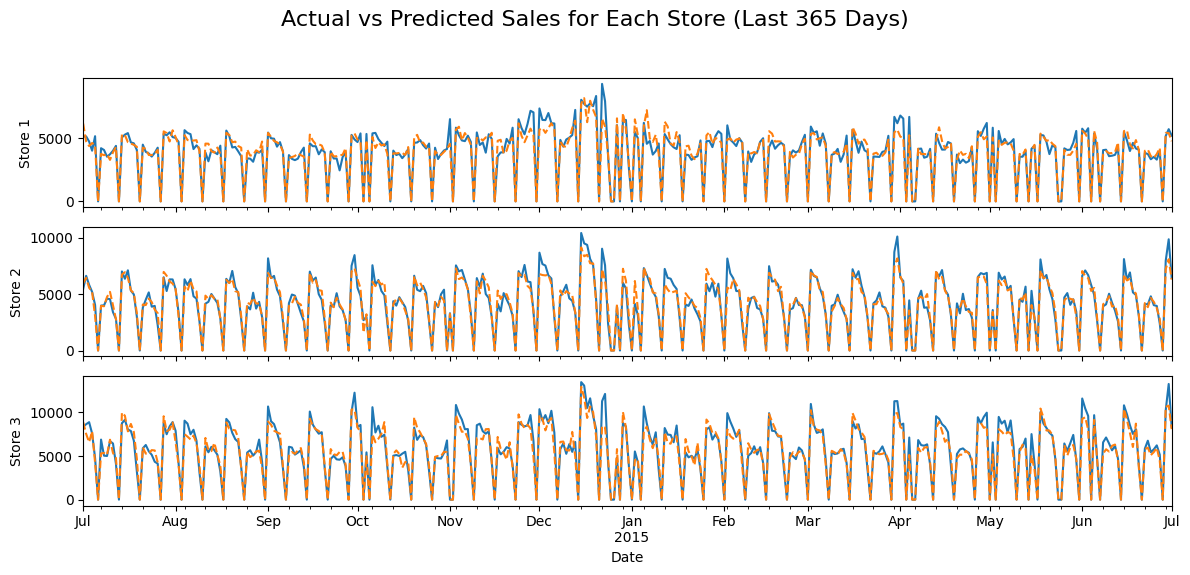

In [6]:
booster = utils.refit(X, y, mock_trial, config.model_constants)
actuals = df.set_index(['Store', 'Date'])['Sales']
preds   = utils.predict(X, booster, trf)
results = pd.merge(actuals, preds, left_index=True, right_index=True, suffixes=('_actual', '_predicted'))
mae     = mean_absolute_error(results["Sales_actual"], results["Sales_predicted"])

print(f"MAE: {mae:.2f}")
plot_actual_vs_predicted(results, 365, 30)

# End-to-end `optimize`

Runs a couple of Optuna trials through the new `optimize`. Set `n_trials` small for a quick check.

Best trial: #1
Best value (rmse): 0.123260
Best params: {'max_depth': 4, 'learning_rate': 0.020004664149351287, 'subsample': 0.8142879919787589, 'colsample_bytree': 0.9510580360198695, 'min_child_weight': 4, 'reg_alpha': 0.01792495509428975, 'reg_lambda': 0.0036505060359653917, 'gamma': 0.8956338336270271}
Refit MAE: 588.62


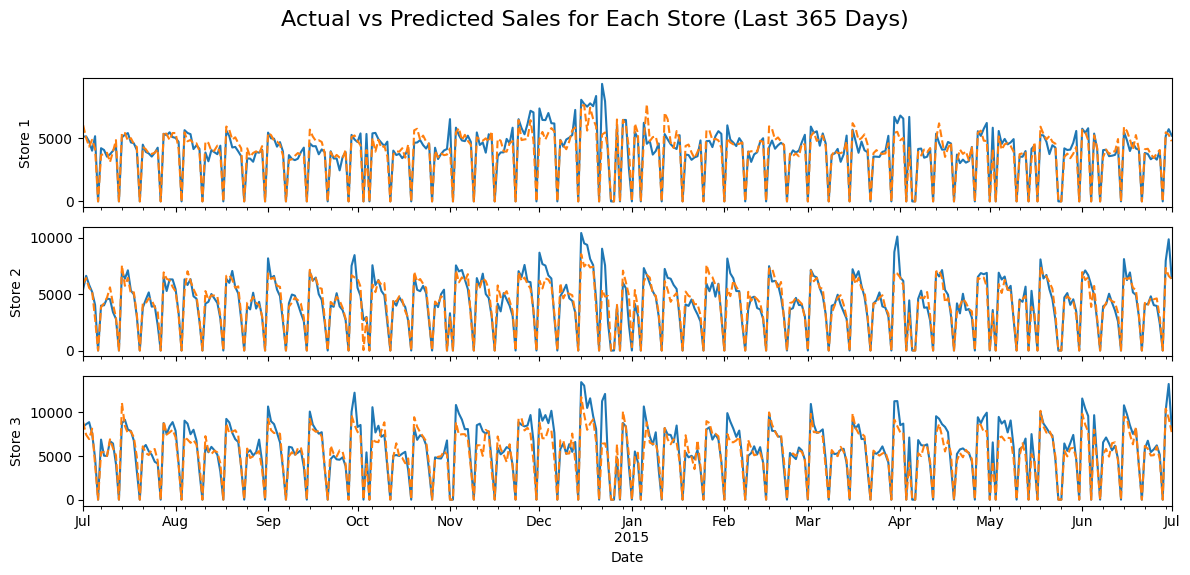

In [ ]:
# get current timestamp
now = pd.Timestamp.now().strftime("%Y%m%d_%H%M%S")
hypertuning.optimize(study_name=f'smoke_study_{now}',
                     X_train=X,
                     y_train=y,
                     cv_settings=cv_sizes,
                     config=config)

study = optuna.load_study(study_name=f'smoke_study_{now}',
                          storage=config.path.storage_url)

# Refit a model on the full dataset using the best hyperparameters
best_bst   = utils.refit(X, y, study.best_trial, config.model_constants)
best_preds = utils.predict(X, best_bst, trf)
actuals    = df.set_index(['Store', 'Date'])['Sales']
best_res   = pd.merge(actuals, best_preds, left_index=True, right_index=True, suffixes=('_actual', '_predicted'))
best_mae   = mean_absolute_error(best_res["Sales_actual"], best_res["Sales_predicted"])

print(f"Best trial: #{study.best_trial.number}")
print(f"Best value ({config.model_constants.eval_metric}): {study.best_trial.value:.6f}")
print(f"Best params: {study.best_trial.params}")
print(f"Refit MAE: {best_mae:.2f}")
plot_actual_vs_predicted(best_res, 365, 30)

# Nested cross-validation (out-of-fold predictions)

Run 3 outer folds, each test window equal to `FORECAST_HORIZON` steps per store. On every outer fold we tune hyperparameters on the training portion, refit with the best params, and predict the held-out test window. The out-of-fold predictions are then collected and plotted per store.

In [ ]:
from sklearn.metrics import mean_absolute_error

num_days = X.index.get_level_values("Date").nunique()
cv_sizes = utils.compute_cv_sizes(num_days, config['forecast_horizon'], config['n_outer_splits'], config['n_inner_splits'])
config.update(cv_sizes)  # Update config with calculated CV sizes

outer_cv = TimeSeriesCV(n_splits=config['n_outer_splits'],
                        train_size=config['outer_train_size'],
                        test_size=config['outer_test_size'],
                        gap=config['forecast_horizon'])

oof_preds = []
for fold, (train_idx, test_idx) in enumerate(outer_cv.split(X), start=1):

    print(f"\n=== Outer fold {fold}/{config['n_outer_splits']}")

    # Split the data into training and test sets for the current outer fold
    X_train = X.iloc[train_idx]
    y_train = y.iloc[train_idx]
    X_test  = X.iloc[test_idx]

    # 1) Hyperparameter tuning on the outer-fold training data (embargoed inner CV inside optimize).
    study_name = f"nested_outer_{fold}"
    hypertuning.optimize(study_name=study_name, X_train=X_train, y_train=y_train, config=config)

    # 2) Refit on the outer-fold training data using the best hyperparameters.
    study = optuna.load_study(study_name=study_name, storage=config["storage_url"])
    model = utils.refit(X_train, y_train, study.best_trial, config)

    # 3) Predict the held-out test window and store the out-of-fold predictions.
    fold_preds = utils.predict(X_test, model, trf)  # Use the utility function to get predictions
    oof_preds.append(fold_preds)

# Combine all out-of-fold predictions and invert the target transform.
oof_results = pd.merge(left=df.set_index(['Store', 'Date'])['Sales'],
                       right=pd.concat(oof_preds),
                       left_index=True,
                       right_index=True,
                       suffixes=('_actual', '_predicted')).sort_index()

oof_mae = mean_absolute_error(oof_results["Sales_actual"], oof_results["Sales_predicted"])
print(f"\nOut-of-fold MAE: {oof_mae:.2f}")
plot_actual_vs_predicted(oof_results, 365, 30)